In [16]:
!pip install seaborn

You should consider upgrading via the 'C:\Users\erykb\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

#spacje na NAN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

#tak nie na 1 0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Usunięcie ID
df = df.drop(columns=['customerID'])

# Podział na cechy (X) i cel (y)
X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Trening: {X_train.shape}, Test: {X_test.shape}")

Trening: (5634, 19), Test: (1409, 19)


In [18]:
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = [c for c in X.columns if c not in numeric_features]

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

In [19]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = [c for c in X.columns if c not in numeric_features]

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

print("Sukces: Preprocessor został zdefiniowany. Teraz możesz uruchomić eksperyment.")

Sukces: Preprocessor został zdefiniowany. Teraz możesz uruchomić eksperyment.


In [20]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score

# Definicja funkcji pomocniczej do eksperymentów
def run_experiment(model, param_grid, name):
    print(f"\n--- Rozpoczynam eksperyment dla: {name} ---")
    
    # Tworzymy pełny pipeline: Preprocessing -> Model
    # UWAGA: Obiekt 'preprocessor' musi być już zdefiniowany (zrobiłeś to w poprzednim kroku)
    pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('classifier', model)])
    
    # Konfiguracja walidacji krzyżowej (GridSearchCV)
    # StratifiedKFold dba o balans klas w każdym z 5 podzbiorów (foldów)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    # Szukanie najlepszych parametrów (GridSearch)
    # scoring='roc_auc' -> optymalizujemy pod jakość rankingu (ważne przy Churn!)
    grid_search = GridSearchCV(pipeline, param_grid, cv=cv, scoring='roc_auc', n_jobs=-1, verbose=1)
    
    # Trenowanie (automatycznie robi fit/transform na 5 podziałach)
    grid_search.fit(X_train, y_train)
    
    print(f"Najlepsze parametry: {grid_search.best_params_}")
    print(f"Najlepsze AUC (Cross-Validation): {grid_search.best_score_:.4f}")
    
    # Zwracamy najlepszy znaleziony model
    return grid_search.best_estimator_

In [21]:
#e1
param_grid_lr = {
    'classifier__C': [0.01, 0.1, 1, 10], 
    'classifier__solver': ['liblinear'] 
}
best_lr = run_experiment(LogisticRegression(class_weight='balanced', random_state=42), 
                         param_grid_lr, "Logistic Regression")


--- Rozpoczynam eksperyment dla: Logistic Regression ---
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Najlepsze parametry: {'classifier__C': 10, 'classifier__solver': 'liblinear'}
Najlepsze AUC (Cross-Validation): 0.8462


In [22]:
#e2
param_grid_rf = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [5, 10, None],
    'classifier__min_samples_leaf': [2, 5]
}
best_rf = run_experiment(RandomForestClassifier(class_weight='balanced', random_state=42), 
                         param_grid_rf, "Random Forest")


--- Rozpoczynam eksperyment dla: Random Forest ---
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Najlepsze parametry: {'classifier__max_depth': 10, 'classifier__min_samples_leaf': 5, 'classifier__n_estimators': 200}
Najlepsze AUC (Cross-Validation): 0.8473



Wyniki dla Logistic Regression (Tuned) na zbiorze TESTOWYM:
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

ROC AUC Score: 0.8406


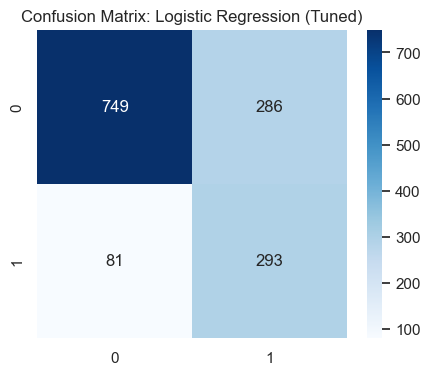


Wyniki dla Random Forest (Tuned) na zbiorze TESTOWYM:
              precision    recall  f1-score   support

           0       0.89      0.76      0.82      1035
           1       0.53      0.75      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.76      0.77      1409

ROC AUC Score: 0.8422


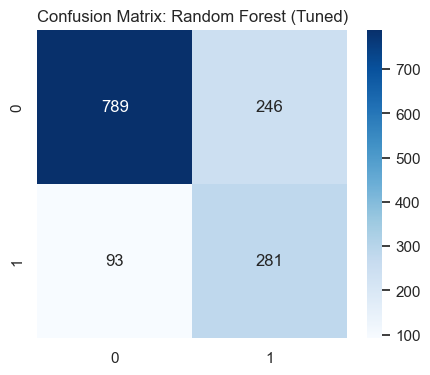

In [60]:
#ocena koncowa
def evaluate_model(model, name, save):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    print(f"\nWyniki dla {name} na zbiorze TESTOWYM:")
    print(classification_report(y_test, y_pred))
    print(f"ROC AUC Score: {roc_auc_score(y_test, y_prob):.4f}")
    
    # Macierz pomyłek
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix: {name}')
    plt.savefig(save)
    plt.show()
    return y_prob

# Ewaluacja
probs_lr = evaluate_model(best_lr, "Logistic Regression (Tuned)", 'Wykres8.png')
probs_rf = evaluate_model(best_rf, "Random Forest (Tuned)", 'Wykres9.png')

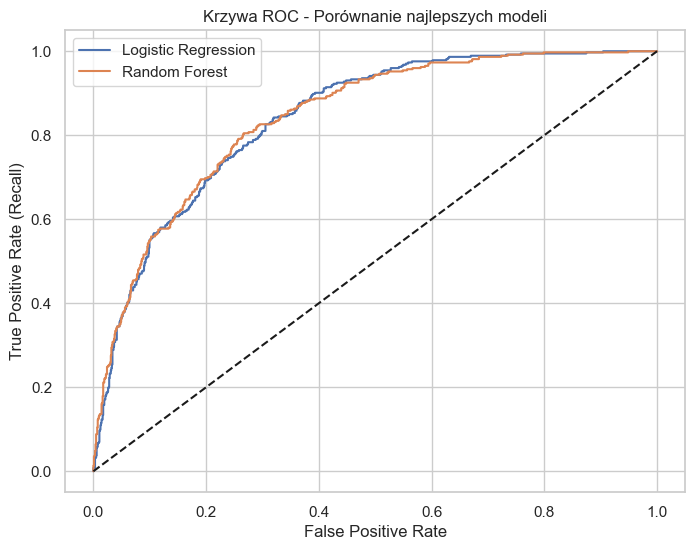

In [59]:
#krzywe
fpr_lr, tpr_lr, _ = roc_curve(y_test, probs_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, probs_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label='Logistic Regression')
plt.plot(fpr_rf, tpr_rf, label='Random Forest')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Krzywa ROC - Porównanie najlepszych modeli')
plt.legend()
plt.savefig('Wykres6.png')
plt.show()

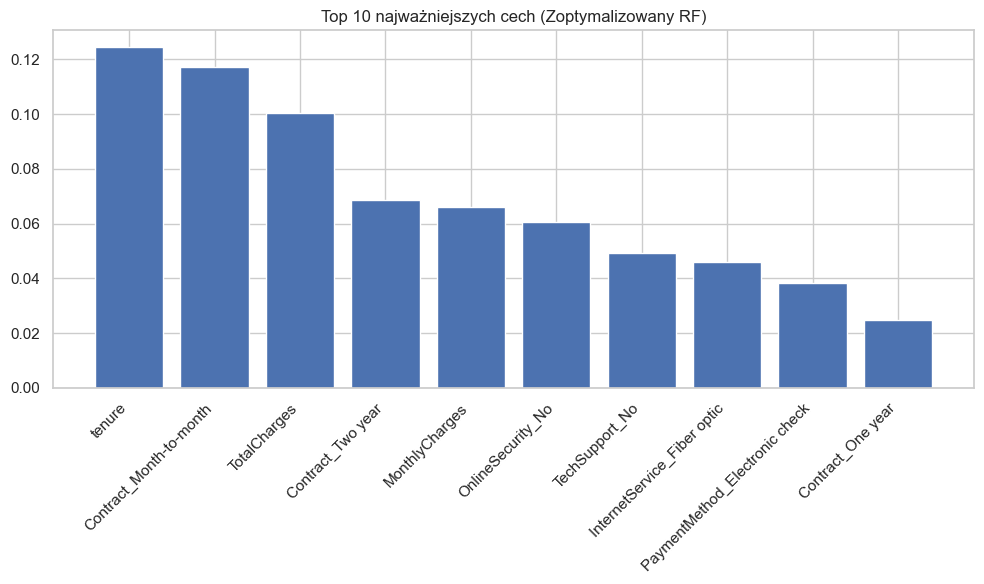

In [61]:
#cechy
model_rf_inner = best_rf.named_steps['classifier']
preprocessor_inner = best_rf.named_steps['preprocessor']

# Pobranie nazw cech
ohe_cols = preprocessor_inner.named_transformers_['cat']['onehot'].get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(ohe_cols)

# Wykres ważności
importances = model_rf_inner.feature_importances_
indices = np.argsort(importances)[::-1][:10]

plt.figure(figsize=(10, 6))
plt.title("Top 10 najważniejszych cech (Zoptymalizowany RF)")
plt.bar(range(10), importances[indices])
plt.xticks(range(10), np.array(all_feature_names)[indices], rotation=45, ha='right')
plt.tight_layout()
plt.savefig('Wykres10.jpg')
plt.show()

=== START ANALIZY EDA (Exploratory Data Analysis) ===


C:\Users\erykb\AppData\Local\Temp\ipykernel_13172\11636773.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Churn', data=df, palette='viridis')


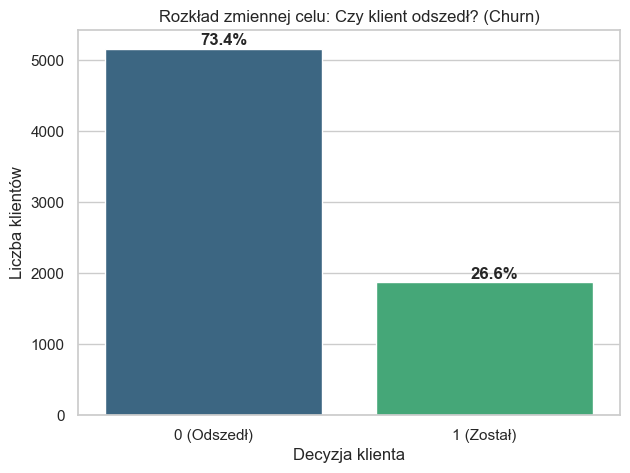

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Ustawienie estetyki wykresów
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(subset=['TotalCharges'], inplace=True)

df['Churn_Numeric'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("=== START ANALIZY EDA (Exploratory Data Analysis) ===")

plt.figure(figsize=(7, 5))
ax = sns.countplot(x='Churn', data=df, palette='viridis')
plt.title('Rozkład zmiennej celu: Czy klient odszedł? (Churn)')
plt.xlabel('Decyzja klienta')
plt.ylabel('Liczba klientów')
plt.xticks([0, 1], ['0 (Odszedł)', '1 (Został)'])

total = len(df)
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_height() + 50
    ax.annotate(percentage, (x, y), weight='bold')
plt.savefig("Wykres1")
plt.show()

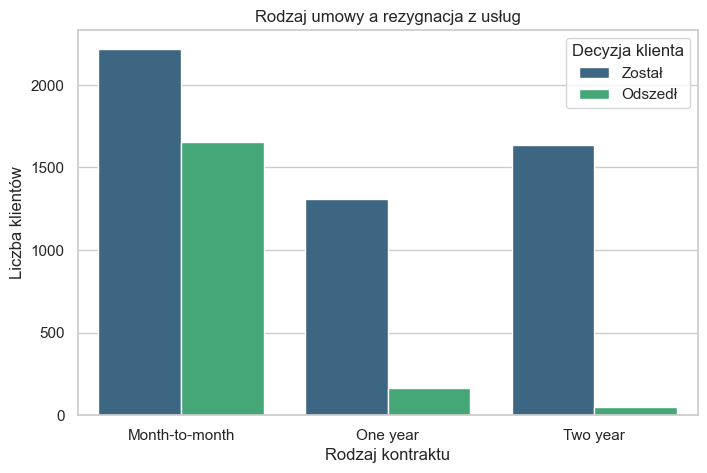

In [63]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Contract', hue='Churn', data=df, palette='viridis')
plt.title('Rodzaj umowy a rezygnacja z usług')
plt.xlabel('Rodzaj kontraktu')
plt.ylabel('Liczba klientów')
plt.legend(title='Decyzja klienta', labels=['Został', 'Odszedł'])
plt.savefig('Wykres2.png')
plt.show()

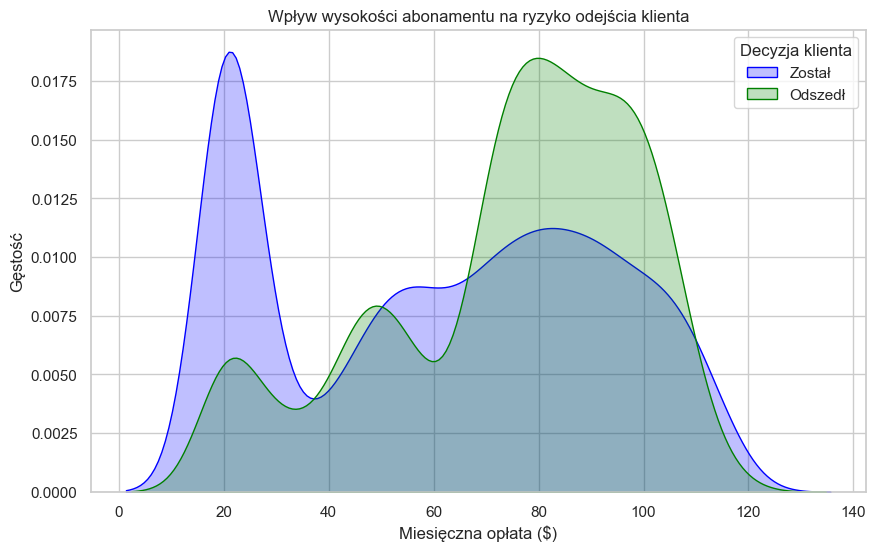

In [64]:
plt.figure(figsize=(10, 6))

sns.kdeplot(df[df['Churn'] == 0]['MonthlyCharges'], color='blue', fill=True, label='Został')
sns.kdeplot(df[df['Churn'] == 1]['MonthlyCharges'], color='green', fill=True, label='Odszedł')

plt.title('Wpływ wysokości abonamentu na ryzyko odejścia klienta')
plt.xlabel('Miesięczna opłata ($)')
plt.ylabel('Gęstość')

plt.legend(title='Decyzja klienta')

plt.savefig('Wykres3.png')
plt.show()

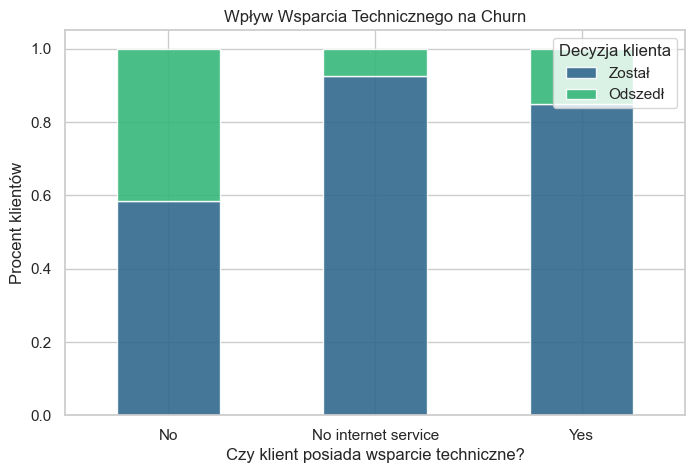

In [65]:
viridis_colors = sns.color_palette("viridis", 2)

tech_support_churn = df.groupby('TechSupport')['Churn'].value_counts(normalize=True).unstack()


ax = tech_support_churn.plot(kind='bar', stacked=True, color=viridis_colors, alpha=0.9, figsize=(8, 5))

plt.title('Wpływ Wsparcia Technicznego na Churn')
plt.xlabel('Czy klient posiada wsparcie techniczne?')
plt.ylabel('Procent klientów')
plt.xticks(rotation=0)

plt.legend(title='Decyzja klienta', labels=['Został', 'Odszedł'], loc='upper right')

plt.savefig('Wykres4.png')
plt.show()

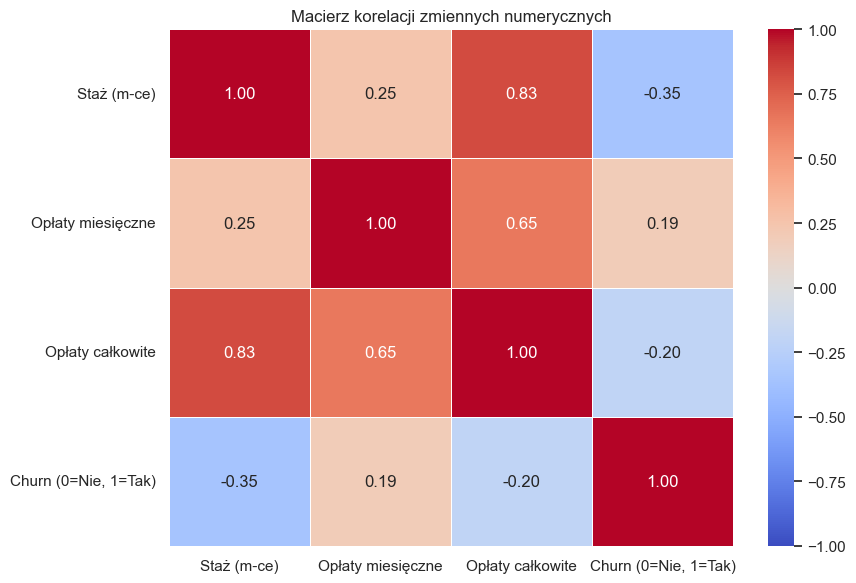

In [66]:
if pd.api.types.is_numeric_dtype(df['Churn']):
    df['Churn_Numeric'] = df['Churn']
else:
    df['Churn_Numeric'] = df['Churn'].map({'Yes': 1, 'No': 0})

numeric_df = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_Numeric']].copy()

numeric_df.columns = ['Staż (m-ce)', 'Opłaty miesięczne', 'Opłaty całkowite', 'Churn (0=Nie, 1=Tak)']

corr_matrix = numeric_df.dropna().corr()

plt.figure(figsize=(9, 6))

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", 
            linewidths=0.5, vmin=-1, vmax=1)

plt.title('Macierz korelacji zmiennych numerycznych')
plt.tight_layout()
plt.savefig('Wykres5.png', bbox_inches='tight')

plt.savefig('Wykres5.png')
plt.show()